In [43]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [44]:
df = pd.read_csv('/content/student-performance-ml-synthetic-2500-updated.csv')

df.head()

,student_id,student_email,student_account_status,student_role,course_id,course_code,course_status,program_name,enrollment_status,enrollment_type,...,open_ticket_count,critical_ticket_count,academic_ticket_count,technical_ticket_count,finance_ticket_count,appointment_count,completed_appointment_count,cancelled_appointment_count,last_activity_days_ago,performance_category
0,415,student0415@student.hitech.lk,PENDING_VERIFICATION,STUDENT,9,DM-SEO-101,ARCHIVED,Software Engineering,REMOVED,OPEN,...,0,1,1,0,0,1,1,0,79,Low
1,510,student0510@student.hitech.lk,ACTIVE,STUDENT,3,SE-DB-130,ACTIVE,Cybersecurity,ACTIVE,OPEN,...,0,0,0,0,0,1,1,0,3,Good
2,429,student0429@student.hitech.lk,ACTIVE,STUDENT,9,DM-SEO-101,ARCHIVED,Software Engineering,REMOVED,OPEN,...,0,0,1,0,0,1,0,1,88,Low
3,45,student0045@student.hitech.lk,ACTIVE,STUDENT,4,DS-PY-101,ACTIVE,Business Management,COMPLETED,OPEN,...,0,0,0,0,0,0,0,0,2,Good
4,503,student0503@student.hitech.lk,ACTIVE,STUDENT,11,CC-AWS-101,ACTIVE,Cybersecurity,COMPLETED,ADMIN_ONLY,...,0,1,0,0,1,0,0,0,30,Medium


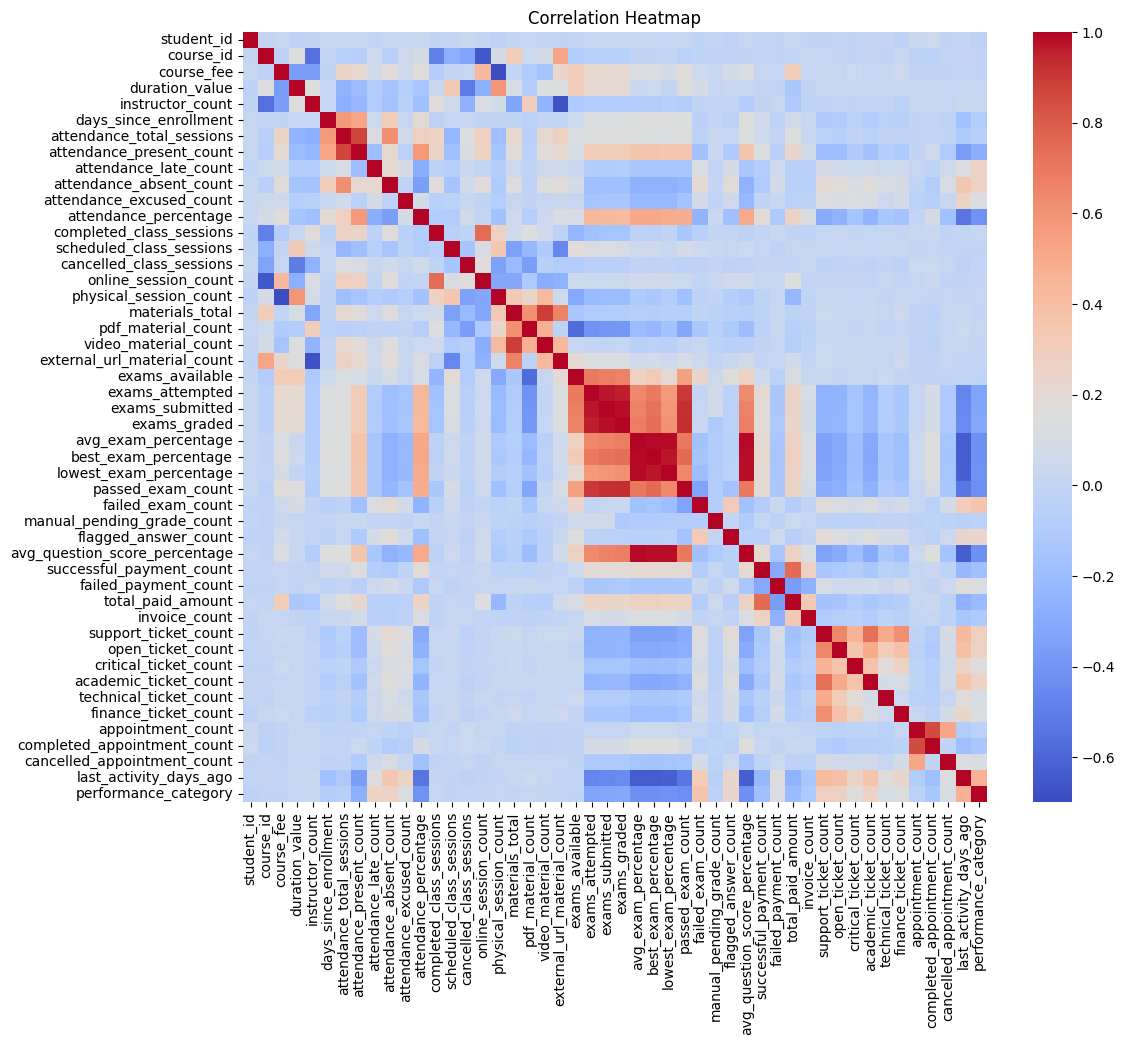

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Copy dataset
viz_df = df.copy()

# Encode target for correlation
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
viz_df["performance_category"] = le.fit_transform(viz_df["performance_category"])

# Select only numeric columns
numeric_df = viz_df.select_dtypes(include=["int64", "float64"])

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [46]:
print("Rows and columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Rows and columns: (2500, 58)

Columns:
['student_id', 'student_email', 'student_account_status', 'student_role', 'course_id', 'course_code', 'course_status', 'program_name', 'enrollment_status', 'enrollment_type', 'course_fee', 'duration_value', 'duration_unit', 'instructor_count', 'days_since_enrollment', 'attendance_total_sessions', 'attendance_present_count', 'attendance_late_count', 'attendance_absent_count', 'attendance_excused_count', 'attendance_percentage', 'completed_class_sessions', 'scheduled_class_sessions', 'cancelled_class_sessions', 'online_session_count', 'physical_session_count', 'materials_total', 'pdf_material_count', 'video_material_count', 'external_url_material_count', 'exams_available', 'exams_attempted', 'exams_submitted', 'exams_graded', 'avg_exam_percentage', 'best_exam_percentage', 'lowest_exam_percentage', 'passed_exam_count', 'failed_exam_count', 'manual_pending_grade_count', 'flagged_answer_count', 'avg_question_score_percentage', 'payment_status', 'succes

In [47]:
df.isnull().sum()

,0
student_id,0
student_email,0
student_account_status,0
student_role,0
course_id,0
course_code,0
course_status,0
program_name,0
enrollment_status,0
enrollment_type,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 58 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     2500 non-null   int64  
 1   student_email                  2500 non-null   object 
 2   student_account_status         2500 non-null   object 
 3   student_role                   2500 non-null   object 
 4   course_id                      2500 non-null   int64  
 5   course_code                    2500 non-null   object 
 6   course_status                  2500 non-null   object 
 7   program_name                   2500 non-null   object 
 8   enrollment_status              2500 non-null   object 
 9   enrollment_type                2500 non-null   object 
 10  course_fee                     2500 non-null   float64
 11  duration_value                 2500 non-null   int64  
 12  duration_unit                  2500 non-null   o

In [49]:
df['performance_category'].value_counts()

,count
performance_category,
Average,747
Medium,692
Good,670
Low,391


In [50]:
df.describe()

,student_id,course_id,course_fee,duration_value,instructor_count,days_since_enrollment,attendance_total_sessions,attendance_present_count,attendance_late_count,attendance_absent_count,...,support_ticket_count,open_ticket_count,critical_ticket_count,academic_ticket_count,technical_ticket_count,finance_ticket_count,appointment_count,completed_appointment_count,cancelled_appointment_count,last_activity_days_ago
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000
mean,425.21720,6.586000,41446.000000,8.229200,1.566000,100.778800,9.28600,5.447600,1.176400,2.318400,...,0.776000,0.264000,0.089200,0.332400,0.173600,0.27000,0.772800,0.547200,0.22560,21.697200
std,247.64451,3.476584,8051.398264,4.681435,0.631984,61.115516,6.14043,5.072509,1.095885,2.498543,...,1.001511,0.581755,0.311901,0.634091,0.423716,0.52954,0.889886,0.759475,0.47201,20.626694
min,1.00000,1.000000,25000.000000,3.000000,1.000000,5.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000
25%,208.00000,4.000000,35000.000000,4.000000,1.000000,52.000000,4.00000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,6.000000
50%,430.00000,7.000000,45000.000000,8.000000,1.000000,88.000000,8.00000,4.000000,1.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.00000,15.000000
75%,639.00000,10.000000,50000.000000,12.000000,2.000000,139.000000,13.00000,8.000000,2.000000,3.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.00000,1.000000,1.000000,0.00000,31.000000
max,850.00000,12.000000,50000.000000,16.000000,3.000000,326.000000,28.00000,28.000000,7.000000,17.000000,...,6.000000,5.000000,3.000000,5.000000,3.000000,3.00000,6.000000,5.000000,3.00000,117.000000


In [52]:
selected_features = [
    "enrollment_status",
    "days_since_enrollment",
    "attendance_percentage",
    "attendance_absent_count",   # corrected column name
    "exams_attempted",
    "exams_submitted",
    "avg_exam_percentage",
    "passed_exam_count",
    "failed_exam_count",
    "last_activity_days_ago",
]

X = df[selected_features]
y = df["performance_category"]

In [53]:
X = df[selected_features].copy()
y = df["performance_category"]

enrollment_encoder = LabelEncoder()
X["enrollment_status"] = enrollment_encoder.fit_transform(X["enrollment_status"])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Enrollment status mapping:")
for i, label in enumerate(enrollment_encoder.classes_):
    print(i, "=", label)

print("\nTarget mapping:")
for i, label in enumerate(target_encoder.classes_):
    print(i, "=", label)

Enrollment status mapping:
0 = ACTIVE
1 = COMPLETED
2 = REMOVED

Target mapping:
0 = Average
1 = Good
2 = Low
3 = Medium


In [54]:
y = le.fit_transform(y)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [58]:
y_pred = model.predict(X_test)

In [57]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['performance_category'])

print("Target label mapping:")
for index, label in enumerate(target_encoder.classes_):
    print(index, "=", label)

Target label mapping:
0 = Average
1 = Good
2 = Low
3 = Medium


In [59]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.876

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84       150
           1       0.92      0.89      0.90       134
           2       0.92      0.90      0.91        78
           3       0.85      0.88      0.87       138

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



In [60]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))

Accuracy: 0.876
              precision    recall  f1-score   support

     Average       0.84      0.85      0.84       150
        Good       0.92      0.89      0.90       134
         Low       0.92      0.90      0.91        78
      Medium       0.85      0.88      0.87       138

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



In [40]:
joblib.dump(model, "student_performance_model.pkl")
joblib.dump(target_encoder, "target_label_encoder.pkl")
joblib.dump(enrollment_encoder, "enrollment_status_encoder.pkl")
joblib.dump(selected_features, "selected_features.pkl")

['selected_features.pkl']

In [41]:
from google.colab import files

files.download("student_performance_model.pkl")
files.download("target_label_encoder.pkl")
files.download("enrollment_status_encoder.pkl")
files.download("selected_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>